# Dissertation Update - March

| Original Question | New Potential Question |
| ----------------- | ---------------------- |
| Can incorporating human-inspired heuristics into the operators of a genetic algorithm lead to more realistic evacuation routing patterns compared to a standard GA and a greedy in multi-agent evacuation modelling? | Does globally optimised mult-agent routing via Genetic Algorithms produce better evacuation outcomes than individual greedy path routing? |


In order to evaluate if the genetic algorithm produces better overall outcomes I will look at the following metrics:

| Metric | Description | Hypothesis |
| ------ | ----------- | ---------- |
| Average Path Length | For all the agents what is the average length of the path from start to finish | Expect the greedy algorithms path to be shorter than the GA |
| Total Time | This the maximum amount of time it takes for all agents to get from a start node to an exit (i.e. full evacuation), this is a calculation of path length plus any congestion penalties. This is also the value the fitness function is trying to minimise | Expect the GA to have a better overall total time |
| Average Time | The average time it takes the agents to get from a start to an exit | Why do I care about this? |
| Exit Utilisation | This maps the number of agents using each of the exits in the simulation | Expect the GA to use more exits than the Greedy algorithm |
| Congestion Index | This is a true / false indicator to see if an agent is affected by congestion at any point during the evacuation | Expect GA to have agents impacted less by congestion |
| Congestion Delay | This is the number of penalty time steps added to the agents path due to congestion on a node on average across all the agents | Again expect GA to have a lower average congestion delay |

In [1]:
%load_ext autoreload
%autoreload 2

I have 3 different city environments that I will test the algorithms on:
* Open City - where there are lots of routes from start points to exits.
* Constrainted City - there are limited routes from start to end points, this route should show high signs of congestion.
* Moderate City - this is a middle ground between the above two cities, there will be alternative routes but still likely will have some signs of congestion.

## Algorithm Performance

In [57]:
import numpy as np
from tqdm import tqdm


n_experiments = 10
rng = np.random.default_rng(42)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

num_agents = 50
simulation_params = {"congestion": True, "walking": False, "fitness": "max"}

In [47]:
from utils.environment import Environment 
from utils.algorithm_evaluation import AlgorithmComparison
from multi_agent_ga import simulate_ga_evacuation, simulate_greedy_evacuation

### Constrained City

In [48]:
city = Environment(city_name=constrained_city_name)

In [50]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: constrained_1 | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 15.000 | avg fit: 16.860 | worst fit: 19.000 | avg path: 3.388 | congestion: 8.232 | exit use: 0.136 | diveristy: 0.022
Evolution    5 | best fit: 14.000 | avg fit: 16.020 | worst fit: 19.000 | avg path: 3.332 | congestion: 8.138 | exit use: 0.133 | diveristy: 0.061
Evolution   10 | best fit: 14.000 | avg fit: 15.060 | worst fit: 17.000 | avg path: 3.270 | congestion: 7.794 | exit use: 0.113 | diveristy: 0.090
Evolution   15 | best fit: 14.000 | avg fit: 14.840 | worst fit: 16.000 | avg path: 3.279 | congestion: 7.718 | exit use: 0.111 | diveristy: 0.116
Evolution   20 | best fit: 14.000 | avg fit: 1

In [51]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 2.68 | Total time: 20.00 | Average time: 15.68 | Exit utilisation: 0.19 | Avg Path Efficiency: 1.00 | Congestion index: 100% | Avg Congestion delay: 13.00


In [58]:
city = Environment(city_name=constrained_city_name)

greedy_outputs, ga_outputs = [], []
for seed_idx in tqdm(range(n_experiments)):
    _ , greedy_evaluation = simulate_greedy_evacuation(
        num_agents=num_agents,
        simulation_params=simulation_params,
        algorithm_seed=algorithm_seeds[seed_idx],
        city=city,
        verbose=False
    )
    greedy_outputs.append(greedy_evaluation)
    
    _ , ga_evaluation = simulate_ga_evacuation(
        city=city,
        num_agents=num_agents,
        population_size=50,
        algorithm_seed=algorithm_seeds[seed_idx],
        max_evolutions=50,
        simulation_params=simulation_params,
        verbose=0,
    )
    ga_outputs.append(ga_evaluation) 
            

100%|██████████| 10/10 [07:24<00:00, 44.44s/it]


In [59]:
comparison = AlgorithmComparison(greedy_outputs=greedy_outputs, ga_outputs=ga_outputs)
results = comparison.statistical_tests(verbose=True)

Total time p-value: 0.002 (Significant: True)
Average time p-value: 0.002 (Significant: True)
Avg Congestion delay p-value: 0.002 (Significant: True)
Exit utilisation p-value: 1.000 (Significant: False)
Avg Path Efficiency p-value: 0.002 (Significant: True)


In [60]:
price_of_anarchy = comparison.price_of_anarchy(verbose=True)

Price of Anarchy: 1.844 ± 0.292


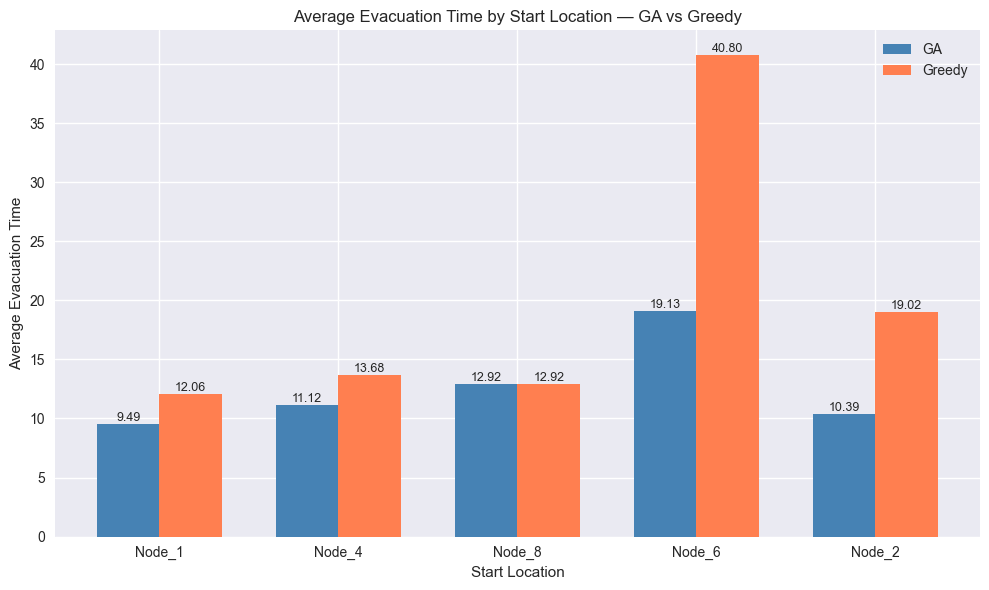

In [62]:
comparison.plot_exit_time_by_start_location()


### Moderate City

In [63]:
city = Environment(city_name=moderate_city_name)

In [70]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: flexible_1 | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 20.000 | avg fit: 21.860 | worst fit: 22.000 | avg path: 4.548 | congestion: 7.322 | exit use: 0.133 | diveristy: 0.043
Evolution    5 | best fit: 20.000 | avg fit: 21.360 | worst fit: 24.000 | avg path: 4.611 | congestion: 7.280 | exit use: 0.142 | diveristy: 0.187
Evolution   10 | best fit: 19.000 | avg fit: 20.880 | worst fit: 24.000 | avg path: 4.673 | congestion: 7.090 | exit use: 0.155 | diveristy: 0.245
Evolution   15 | best fit: 19.000 | avg fit: 20.540 | worst fit: 23.000 | avg path: 4.761 | congestion: 6.890 | exit use: 0.130 | diveristy: 0.301
Evolution   20 | best fit: 18.000 | avg fit: 19.9

In [71]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 2.54 | Total time: 39.00 | Average time: 33.30 | Exit utilisation: 0.00 | Avg Path Efficiency: 1.00 | Congestion index: 100% | Avg Congestion delay: 30.76


In [72]:
comparison = AlgorithmComparison(
    greedy_outputs=[greedy_evaluation], ga_outputs=[ga_evaluation]
)
price_of_anarchy = comparison.price_of_anarchy(verbose=True)

Price of Anarchy: 2.600 ± 0.000


### Flexible

In [66]:
city = Environment(city_name=flexible_city_name)

In [67]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: flexible_1 | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 20.000 | avg fit: 21.860 | worst fit: 22.000 | avg path: 4.548 | congestion: 7.322 | exit use: 0.133 | diveristy: 0.043
Evolution    5 | best fit: 20.000 | avg fit: 21.360 | worst fit: 24.000 | avg path: 4.611 | congestion: 7.280 | exit use: 0.142 | diveristy: 0.187
Evolution   10 | best fit: 19.000 | avg fit: 20.880 | worst fit: 24.000 | avg path: 4.673 | congestion: 7.090 | exit use: 0.155 | diveristy: 0.245
Evolution   15 | best fit: 19.000 | avg fit: 20.540 | worst fit: 23.000 | avg path: 4.761 | congestion: 6.890 | exit use: 0.130 | diveristy: 0.301
Evolution   20 | best fit: 18.000 | avg fit: 19.9

In [68]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 2.54 | Total time: 39.00 | Average time: 33.30 | Exit utilisation: 0.00 | Avg Path Efficiency: 1.00 | Congestion index: 100% | Avg Congestion delay: 30.76


In [69]:
comparison = AlgorithmComparison(
    greedy_outputs=[greedy_evaluation], ga_outputs=[ga_evaluation]
)
price_of_anarchy = comparison.price_of_anarchy(verbose=True)

Price of Anarchy: 2.600 ± 0.000


## Compliance Rate
How does the genetic algorithm's advantage change with compliance rate?

* Do this after calculated the routes and change some agents (i.e. the genetic algorithm doesn't know about the non-compliance).
* run this for different non-compliance rates (where 0% is ga and 100% is greedy). 